In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
from  matplotlib import pyplot as plt

from util import create_dataframes, pair_images

In [12]:
df, full_mammograms_df, roi_masks_df, _ = create_dataframes()
paired_df, merged_df = pair_images(roi_masks_df, full_mammograms_df)

Successfully paired 3242 mammogram/ROI pairs.
Removed 78 entries due to mismatched dimensions.
Consolidated into 2742 image entries.


In [13]:
mass_info_df = pd.read_csv('../data/cbis-ddsm/csv/all_merged.csv')

# Class Distribution

In [14]:
class_counts = mass_info_df['pathology'].value_counts()

# Rename the BENIGN_WITHOUT_CALLBACK column to B_NO_CB to fit in class distribution graph
class_counts.rename({'BENIGN_WITHOUT_CALLBACK': 'B_NO_CB'}, axis=0, inplace=True)

# Combine the BENIGN and B_NO_CB columns into a single column named B_ALL
class_counts['B_ALL'] = class_counts['BENIGN'] + class_counts['B_NO_CB']

class_counts

pathology
MALIGNANT    1457
BENIGN       1429
B_NO_CB       682
B_ALL        2111
Name: count, dtype: int64

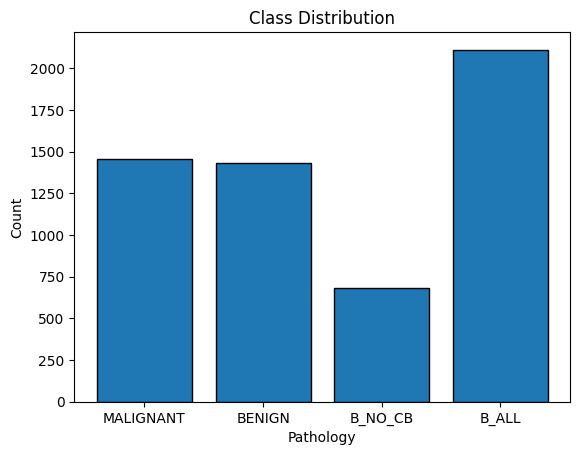

In [15]:
plt.bar(class_counts.index, class_counts.values, edgecolor='black')
plt.xlabel('Pathology')
plt.ylabel('Count')
plt.title('Class Distribution')
plt.show()

In [16]:
total_len = len(mass_info_df)

percent_malignant = class_counts['MALIGNANT'] / total_len
percent_benign = class_counts['B_ALL'] / total_len

print(f'Malignant: {percent_malignant:.2%} | Benign: {percent_benign:.2%}')

Malignant: 40.84% | Benign: 59.16%


# Images with More than one ROI

In [17]:
# Get images that appear at least twice in the dataframe
duplicates = mass_info_df[mass_info_df.duplicated(subset=['image file path'], keep=False)].reset_index(drop=True)

duplicates

,patient_id,breast_density,left or right breast,image view,abnormality id,abnormality type,mass shape,mass margins,assessment,pathology,subtlety,image file path,cropped image file path,ROI mask file path,breast density,calc type,calc distribution
0,P_00116,2.0,RIGHT,CC,1,mass,IRREGULAR-ARCHITECTURAL_DISTORTION,SPICULATED,5,MALIGNANT,5,Mass-Test_P_00116_RIGHT_CC/1.3.6.1.4.1.9590.10...,Mass-Test_P_00116_RIGHT_CC_1/1.3.6.1.4.1.9590....,Mass-Test_P_00116_RIGHT_CC_1/1.3.6.1.4.1.9590....,NaN,NaN,NaN
1,P_00116,2.0,RIGHT,CC,2,mass,IRREGULAR-ARCHITECTURAL_DISTORTION,SPICULATED,5,MALIGNANT,5,Mass-Test_P_00116_RIGHT_CC/1.3.6.1.4.1.9590.10...,Mass-Test_P_00116_RIGHT_CC_2/1.3.6.1.4.1.9590....,Mass-Test_P_00116_RIGHT_CC_2/1.3.6.1.4.1.9590....,NaN,NaN,NaN
2,P_00116,2.0,RIGHT,MLO,1,mass,IRREGULAR-ARCHITECTURAL_DISTORTION,SPICULATED,5,MALIGNANT,5,Mass-Test_P_00116_RIGHT_MLO/1.3.6.1.4.1.9590.1...,Mass-Test_P_00116_RIGHT_MLO_1/1.3.6.1.4.1.9590...,Mass-Test_P_00116_RIGHT_MLO_1/1.3.6.1.4.1.9590...,NaN,NaN,NaN
3,P_00116,2.0,RIGHT,MLO,2,mass,IRREGULAR-ARCHITECTURAL_DISTORTION,SPICULATED,5,MALIGNANT,5,Mass-Test_P_00116_RIGHT_MLO/1.3.6.1.4.1.9590.1...,Mass-Test_P_00116_RIGHT_MLO_2/1.3.6.1.4.1.9590...,Mass-Test_P_00116_RIGHT_MLO_2/1.3.6.1.4.1.9590...,NaN,NaN,NaN
4,P_00173,2.0,RIGHT,CC,1,mass,OVAL,CIRCUMSCRIBED,3,BENIGN,5,Mass-Test_P_00173_RIGHT_CC/1.3.6.1.4.1.9590.10...,Mass-Test_P_00173_RIGHT_CC_1/1.3.6.1.4.1.9590....,Mass-Test_P_00173_RIGHT_CC_1/1.3.6.1.4.1.9590....,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
753,P_01864,NaN,RIGHT,MLO,1,calcification,NaN,NaN,2,BENIGN_WITHOUT_CALLBACK,4,Calc-Training_P_01864_RIGHT_MLO/1.3.6.1.4.1.95...,Calc-Training_P_01864_RIGHT_MLO_1/1.3.6.1.4.1....,Calc-Training_P_01864_RIGHT_MLO_1/1.3.6.1.4.1....,2.0,LUCENT_CENTER,NaN
754,P_01864,NaN,RIGHT,MLO,2,calcification,NaN,NaN,2,BENIGN_WITHOUT_CALLBACK,4,Calc-Training_P_01864_RIGHT_MLO/1.3.6.1.4.1.95...,Calc-Training_P_01864_RIGHT_MLO_2/1.3.6.1.4.1....,Calc-Training_P_01864_RIGHT_MLO_2/1.3.6.1.4.1....,2.0,VASCULAR,NaN
755,P_01864,NaN,RIGHT,MLO,3,calcification,NaN,NaN,2,BENIGN_WITHOUT_CALLBACK,4,Calc-Training_P_01864_RIGHT_MLO/1.3.6.1.4.1.95...,Calc-Training_P_01864_RIGHT_MLO_3/1.3.6.1.4.1....,Calc-Training_P_01864_RIGHT_MLO_3/1.3.6.1.4.1....,2.0,VASCULAR,NaN
756,P_01875,NaN,RIGHT,CC,1,calcification,NaN,NaN,2,BENIGN_WITHOUT_CALLBACK,4,Calc-Training_P_01875_RIGHT_CC/1.3.6.1.4.1.959...,Calc-Training_P_01875_RIGHT_CC_1/1.3.6.1.4.1.9...,Calc-Training_P_01875_RIGHT_CC_1/1.3.6.1.4.1.9...,1.0,VASCULAR,NaN


In [18]:
print(f'Found {duplicates['image file path'].nunique()} images with at least 2 ROI masks.')

Found 293 images with at least 2 ROI masks.


In [19]:
# Get the patient ID from the first duplicate image
pid = duplicates.iloc[0]['image file path']
pid = pid[:pid.index('/')]
pid

'Mass-Test_P_00116_RIGHT_CC'

In [20]:
# Find the entry in the paired_df that corresponds to this patient ID
duplicate_idx = paired_df[paired_df['PatientID_full'] == pid].index[0]
paired_df.iloc[duplicate_idx]

image_path_full    ../data/cbis-ddsm/jpeg/1.3.6.1.4.1.9590.100.1....
image_path_roi     [../data/cbis-ddsm/jpeg/1.3.6.1.4.1.9590.100.1...
PatientID_full                            Mass-Test_P_00116_RIGHT_CC
base_id                                   Mass-Test_P_00116_RIGHT_CC
Name: 633, dtype: object